<a href="https://colab.research.google.com/github/fralfaro/ICS40125/blob/main/docs/labs/lab_07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ICS40125 - Laboratorio N°07

**Objetivo**: Aplicar técnicas básicas de **Machine Learning** (tanto regresión como clasificación), desde la preparación de datos hasta el entrenamiento y evaluación de modelos.

> **Nota**: Puede ayudarse de algún asistente virtual como **ChatGPT, Gemini** u otros, así como del autocompletado de **Google Colab**, para avanzar en este laboratorio debido a su extensión.



## Regresión


<img src="https://cdn-icons-png.flaticon.com/512/2400/2400362.png" width = "300" align="center"/>


Los datos utilizados corresponden a propiedades localizadas en un distrito específico de California, junto con algunas estadísticas resumen extraídas del censo de 1990. Es importante tener en cuenta que los datos no han sido procesados previamente, por lo que será necesario realizar algunas etapas de limpieza y preprocesamiento.

Las columnas incluidas en el conjunto de datos son las siguientes (sus nombres son descriptivos):

* **longitude**: Longitud geográfica de la propiedad.
* **latitude**: Latitud geográfica de la propiedad.
* **housingmedianage**: Edad media de las viviendas en la zona.
* **total_rooms**: Número total de habitaciones.
* **total_bedrooms**: Número total de dormitorios.
* **population**: Población en el área circundante.
* **households**: Número de hogares en la zona.
* **median_income**: Ingreso medio por hogar.
* **medianhousevalue**: Valor medio de la propiedad.
* **ocean_proximity**: Proximidad al océano.

El objetivo de este análisis es predecir el valor medio de las propiedades utilizando las características proporcionadas.

Para completar este laboratorio, se recomienda seguir la siguiente rúbrica de trabajo:

1. **Definición del problema**: Clarificar el objetivo del análisis y los resultados esperados.
2. **Estadística descriptiva**: Resumir las principales características de los datos a través de medidas estadísticas.
3. **Visualización descriptiva**: Utilizar gráficos para explorar los datos y sus relaciones.
4. **Preprocesamiento**: Realizar los pasos necesarios de limpieza y transformación de los datos.
5. **Selección de modelo**: Comparar al menos cuatro modelos de predicción diferentes.
6. **Métricas y análisis de resultados**: Evaluar el rendimiento de los modelos utilizando métricas apropiadas.
7. **Visualización de resultados del modelo**: Crear gráficos que muestren el desempeño de los modelos.
8. **Conclusiones**: Resumir los hallazgos del análisis.

> **Nota**: Se anima a los estudiantes a desarrollar un análisis más profundo si lo desean. Pueden consultar como referencia el siguiente [enlace](https://www.kaggle.com/camnugent/california-housing-prices).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def regression_metrics(df):
    """
    Aplicar las distintas métricas definidas
    :param df: DataFrame con las columnas: ['y', 'yhat']
    :return: DataFrame con las métricas especificadas
    """
    df_result = pd.DataFrame()

    y_true = df['y']
    y_pred = df['yhat']

    df_result['mae'] = [round(mean_absolute_error(y_true, y_pred), 4)]
    df_result['mse'] = [round(mean_squared_error(y_true, y_pred), 4)]
    df_result['rmse'] = [round(np.sqrt(mean_squared_error(y_true, y_pred)), 4)]
    df_result['mape'] = [round(mean_absolute_percentage_error(y_true, y_pred), 4)]
    df_result['smape'] = [round(2 * mean_absolute_percentage_error(y_true, y_pred) / (mean_absolute_percentage_error(y_true, y_pred) + 100), 4)]

    return df_result

In [3]:
from sklearn.datasets import fetch_california_housing

# Cargar los datos de housing
housing_data = fetch_california_housing(as_frame=True)

# Convertir los datos en un DataFrame de pandas
housing = housing_data['data']
housing['target'] = housing_data['target']

# Visualizar las primeras filas del DataFrame
housing.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


--- Comparativa de Modelos de Regresión ---
                      mae     mse    rmse     mape   smape
Linear Regression  0.5332  0.5559  0.7456  31.9522  0.4843
Ridge Regression   0.5332  0.5558  0.7455  31.9523  0.4843
Random Forest      0.3303  0.2573  0.5072  19.0148  0.3195
Gradient Boosting  0.3716  0.2940  0.5422  21.5254  0.3543


/tmp/ipykernel_4680/4067694593.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_comparativo_reg.index, y=df_comparativo_reg['rmse'], palette='viridis')


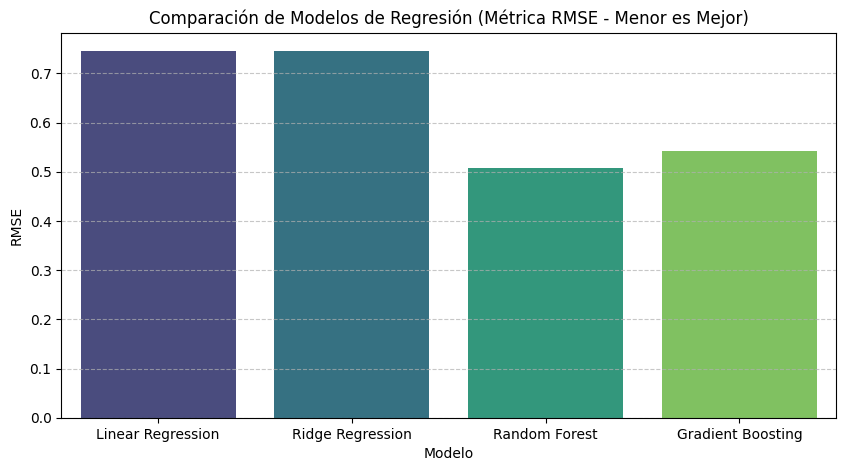

In [10]:
# FIXME
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# 1. Definición de características (X) y variable objetivo (y)
X_reg = housing.drop(columns=['target'])
y_reg = housing['target']

# 2. Dividir en conjuntos de entrenamiento y prueba
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# 3. Instanciar los 4 modelos de regresión
modelos_reg = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Random Forest': RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42)
}

# 4. Entrenar, predecir y evaluar cada modelo
resultados_reg = {}
for nombre, modelo in modelos_reg.items():
    modelo.fit(X_train_r, y_train_r)
    y_pred = modelo.predict(X_test_r)

    # DataFrame temporal para pasar a la función dada 'regression_metrics'
    df_temp = pd.DataFrame({'y': y_test_r, 'yhat': y_pred})
    metricas = regression_metrics(df_temp)
    resultados_reg[nombre] = metricas

# 5. Consolidar todas las métricas en un único DataFrame comparativo
df_comparativo_reg = pd.concat(resultados_reg.values(), keys=resultados_reg.keys()).reset_index(level=1, drop=True)
print("--- Comparativa de Modelos de Regresión ---")
print(df_comparativo_reg)

# 6. Visualización de los Resultados
plt.figure(figsize=(10, 5))
sns.barplot(x=df_comparativo_reg.index, y=df_comparativo_reg['rmse'], palette='viridis')
plt.title('Comparación de Modelos de Regresión (Métrica RMSE - Menor es Mejor)')
plt.ylabel('RMSE')
plt.xlabel('Modelo')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Clasificación


<img src="https://miro.medium.com/v2/resize:fit:372/0*EwdH1C6ThmpwY0Qo.png" width = "400" align="center"/>

El objetivo de este proyecto es realizar la mejor predicción posible de las imágenes a partir de los datos disponibles. Para lograrlo, es necesario seguir los pasos habituales en un proyecto de _Machine Learning_, que incluyen la exploración estadística, la visualización y el preprocesamiento de los datos.

Se solicita lo siguiente:

* Ajustar al menos tres modelos de clasificación:
    * Regresión logística.
    * K-Nearest Neighbors.
    * Un algoritmo adicional o más, de libre elección. Puedes consultar [esta lista de algoritmos](https://scikit-learn.org/stable/supervised_learning.html#supervised-learning) para obtener ideas.
  
* Realizar predicciones con cada uno de los tres modelos utilizando el conjunto de datos de _test_ y calcular sus respectivas puntuaciones (_score_).

* Evaluar y analizar los resultados de los modelos utilizando las siguientes métricas de rendimiento:
    * **Accuracy**
    * **Precision**
    * **Recall**
    * **F1-score**

### Exploración de los datos
A continuación se carga el conjunto de datos a utilizar, a través del sub-módulo `datasets` de `sklearn`.

In [4]:
import numpy as np
import pandas as pd
from sklearn import datasets
import matplotlib.pyplot as plt

%matplotlib inline

In [5]:
digits_dict = datasets.load_digits()
print(digits_dict["DESCR"])

.. _digits_dataset:

Optical recognition of handwritten digits dataset
--------------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 1797
:Number of Attributes: 64
:Attribute Information: 8x8 image of integer pixels in the range 0..16.
:Missing Attribute Values: None
:Creator: E. Alpaydin (alpaydin '@' boun.edu.tr)
:Date: July; 1998

This is a copy of the test set of the UCI ML hand-written digits datasets
https://archive.ics.uci.edu/ml/datasets/Optical+Recognition+of+Handwritten+Digits

The data set contains images of hand-written digits: 10 classes where
each class refers to a digit.

Preprocessing programs made available by NIST were used to extract
normalized bitmaps of handwritten digits from a preprinted form. From a
total of 43 people, 30 contributed to the training set and different 13
to the test set. 32x32 bitmaps are divided into nonoverlapping blocks of
4x4 and the number of on pixels are counted in each block. This generates
an in

In [7]:
# informacion de las columnas
digits_dict.keys()

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])

In [8]:
# informacion del target
digits_dict["target"]

array([0, 1, 2, ..., 8, 9, 8])

A continuación se crea dataframe declarado como `digits` con los datos de `digits_dict` tal que tenga 65 columnas, las 6 primeras a la representación de la imagen en escala de grises (0-blanco, 255-negro) y la última correspondiente al dígito (`target`) con el nombre _target_.

In [9]:
# leer datos
digits = (
    pd.DataFrame(
        digits_dict["data"],
    )
    .rename(columns=lambda x: f"c{x:02d}")
    .assign(target=digits_dict["target"])
    .astype(int)
)

digits.head()

,c00,c01,c02,c03,c04,c05,c06,c07,c08,c09,...,c55,c56,c57,c58,c59,c60,c61,c62,c63,target
0,0,0,5,13,9,1,0,0,0,0,...,0,0,0,6,13,10,0,0,0,0
1,0,0,0,12,13,5,0,0,0,0,...,0,0,0,0,11,16,10,0,0,1
2,0,0,0,4,15,12,0,0,0,0,...,0,0,0,0,3,11,16,9,0,2
3,0,0,7,15,13,1,0,0,0,8,...,0,0,0,7,13,13,9,0,0,3
4,0,0,0,1,11,0,0,0,0,0,...,0,0,0,0,2,16,4,0,0,4


### Ejercicio 1
**Análisis exploratorio:** Realiza tu análisis exploratorio, no debes olvidar nada! Recuerda, cada análisis debe responder una pregunta.

Algunas sugerencias:

* ¿Cómo se distribuyen los datos?
* ¿Cuánta memoria estoy utilizando?
* ¿Qué tipo de datos son?
* ¿Cuántos registros por clase hay?
* ¿Hay registros que no se correspondan con tu conocimiento previo de los datos?

In [ ]:
# FIXME

### Ejercicio 2
**Visualización:** Para visualizar los datos utilizaremos el método `imshow` de `matplotlib`. Resulta necesario convertir el arreglo desde las dimensiones (1,64)  a (8,8) para que la imagen sea cuadrada y pueda distinguirse el dígito. Superpondremos además el label correspondiente al dígito, mediante el método `text`. Esto nos permitirá comparar la imagen generada con la etiqueta asociada a los valores. Realizaremos lo anterior para los primeros 25 datos del archivo.

In [ ]:
digits_dict["images"][0]

Visualiza imágenes de los dígitos utilizando la llave `images` de `digits_dict`.

> **Sugerencia**: Utiliza `plt.subplots` y el método `imshow`. Puedes hacer una grilla de varias imágenes al mismo tiempo!

In [ ]:
nx, ny = 5, 5
fig, axs = plt.subplots(nx, ny, figsize=(12, 12))
## FIXME

### Ejercicio 3

**Machine Learning**: En esta parte usted debe entrenar los distintos modelos escogidos desde la librería de `skelearn`. Para cada modelo, debe realizar los siguientes pasos:

* **train-test**
     * Crear conjunto de entrenamiento y testeo (usted determine las proporciones adecuadas).
     * Imprimir por pantalla el largo del conjunto de entrenamiento y de testeo.
  
* **modelo**:
     * Instanciar el modelo objetivo desde la librería sklearn.

* **Métricas**:
     * Graficar matriz de confusión.
     * Analizar métricas de error.



__Preguntas a responder:__

* ¿Cuál modelo es mejor basado en sus métricas?
* ¿Cuál modelo demora menos tiempo en ajustarse?
* ¿Qué modelo escoges?


Largo del conjunto de entrenamiento: 1347
Largo del conjunto de testeo: 450



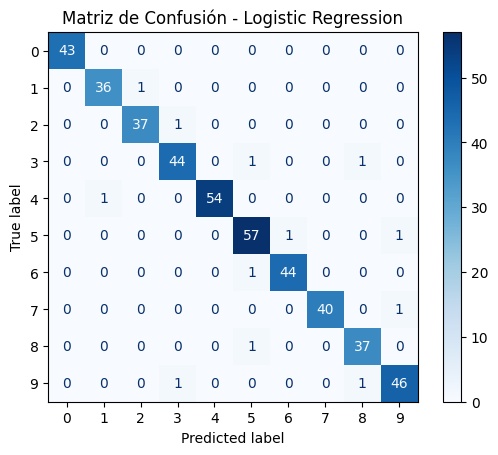

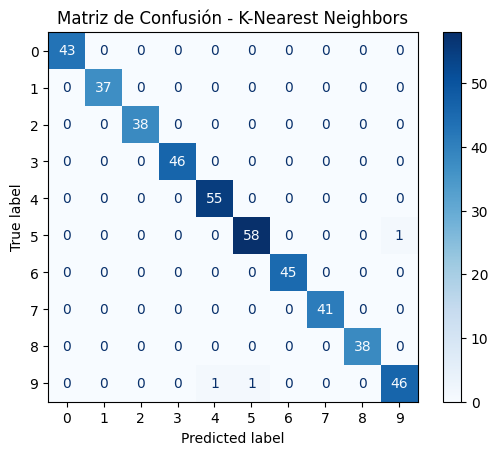

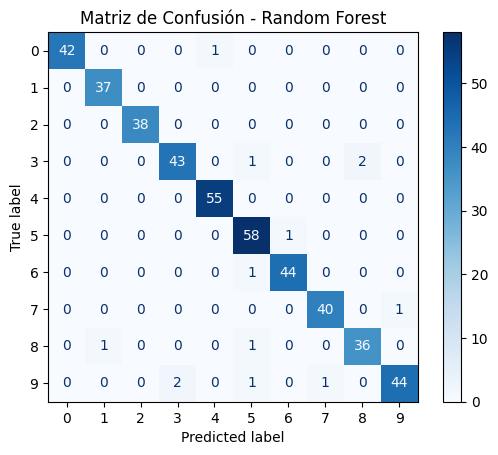


--- Tabla de Rendimiento de Clasificadores ---
             Modelo  Accuracy  Precision  Recall  F1-score  Tiempo Ajuste (s)
Logistic Regression    0.9733     0.9738  0.9737    0.9737             5.5072
K-Nearest Neighbors    0.9933     0.9944  0.9941    0.9942             0.0191
      Random Forest    0.9711     0.9725  0.9712    0.9717             2.0687


In [11]:
# features, target

X = digits.drop(columns="target").values
y = digits["target"].values

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import time

# 1. Preparación de variables de clasificación usando el dataframe 'digits' creado previamente
X_clf = digits.drop(columns=['target'])
y_clf = digits['target']

# 2. Train-Test Split
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clf, y_clf, test_size=0.25, random_state=42)
print(f"Largo del conjunto de entrenamiento: {len(X_train_c)}")
print(f"Largo del conjunto de testeo: {len(X_test_c)}\n")

# 3. Modelos seleccionados
modelos_clf = {
    'Logistic Regression': LogisticRegression(max_iter=10000, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Random Forest': RandomForestClassifier(random_state=42)
}

# 4. Entrenamiento y obtención de Métricas
metricas_clf = []

for nombre, modelo in modelos_clf.items():
    inicio = time.time()
    modelo.fit(X_train_c, y_train_c)
    fin = time.time()
    tiempo_ajuste = fin - inicio

    y_pred = modelo.predict(X_test_c)

    # Cálculo de métricas multiclase (promedio 'macro')
    acc = accuracy_score(y_test_c, y_pred)
    prec = precision_score(y_test_c, y_pred, average='macro')
    rec = recall_score(y_test_c, y_pred, average='macro')
    f1 = f1_score(y_test_c, y_pred, average='macro')

    metricas_clf.append({
        'Modelo': nombre,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-score': round(f1, 4),
        'Tiempo Ajuste (s)': round(tiempo_ajuste, 4)
    })

    # Graficar Matriz de Confusión por cada modelo
    cm = confusion_matrix(y_test_c, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title(f"Matriz de Confusión - {nombre}")
    plt.show()

df_metricas_clf = pd.DataFrame(metricas_clf)
print("\n--- Tabla de Rendimiento de Clasificadores ---")
print(df_metricas_clf.to_string(index=False))

### Ejercicio 4

__Comprensión del modelo:__ Tomando en cuenta el **mejor modelo entontrado** en el `Ejercicio 3`, debe comprender e interpretar minuciosamente los resultados y gráficos asocados al modelo en estudio, para ello debe resolver los siguientes puntos:


 * **Curva AUC–ROC**: Replica el ejemplo del siguiente  [link](https://scikit-learn.org/stable/auto_examples/model_selection/plot_roc.html#sphx-glr-auto-examples-model-selection-plot-roc-py) pero con el modelo, parámetros y métrica adecuada. Saque conclusiones del gráfico.

In [13]:
# FIXME

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from itertools import cycle

# Binarizar el target para enfoque One-vs-Rest (OvR)
y_bin = label_binarize(y_clf, classes=list(range(10)))
n_classes = y_bin.shape[1]

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_bin, y_bin, test_size=0.25, random_state=42)

# Usar Regresión Logística para predecir probabilidades por clase
clf_roc = LogisticRegression(max_iter=10000, random_state=42)
clf_roc.fit(X_train_c, y_train_c)
y_score = clf_roc.predict_proba(X_test_c)

# Calcular curvas ROC por cada dígito (0-9)
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_b[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Graficar
plt.figure(figsize=(10, 7))
colores_ciclo = cycle(['blue', 'red', 'green', 'orange', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan'])
for i, color in zip(range(n_classes), colores_ciclo):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'Clase {i} (AUC = {roc_auc[i]:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curvas ROC Multiclase (One-vs-Rest)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

NameError: name 'X_bin' is not defined

### Ejercicio 5


__Visualizando Resultados:__ A continuación se provee código para comparar las etiquetas predichas vs las etiquetas reales del conjunto de _test_.

In [14]:
def mostrar_resultados(digits, model, nx=5, ny=5, label="correctos"):
    """
    Muestra los resultados de las predicciones de un modelo de clasificación en particular.
    Se toman aleatoriamente los valores de los resultados.

    - label == 'correctos': muestra los valores en los que el modelo acierta.
    - label == 'incorrectos': muestra los valores en los que el modelo no acierta.

    Observación: El modelo que se recibe como argumento no debe estar entrenado.

    :param digits: dataset 'digits'
    :param model: modelo de sklearn
    :param nx: número de filas (subplots)
    :param ny: número de columnas (subplots)
    :param label: 'correctos' o 'incorrectos'
    :return: gráficos matplotlib
    """

    X = digits.drop(columns="target").values
    y = digits["target"].values
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model.fit(X_train, y_train)  # Ajustar el modelo
    y_pred = model.predict(X_test)

    # Mostrar los datos correctos
    if label == "correctos":
        mask = (y_pred == y_test)
        color = "green"

    # Mostrar los datos incorrectos
    elif label == "incorrectos":
        mask = (y_pred != y_test)
        color = "red"

    else:
        raise ValueError("Valor incorrecto")

    X_aux = X_test[mask]
    y_aux_true = y_test[mask]
    y_aux_pred = y_pred[mask]

    # Mostrar los resultados
    n_samples = min(nx * ny, len(X_aux))
    indices = np.random.choice(len(X_aux), n_samples, replace=False)
    fig, ax = plt.subplots(nx, ny, figsize=(12, 12))

    for i, index in enumerate(indices):
        data = X_aux[index, :].reshape(8, 8)
        label_pred = str(int(y_aux_pred[index]))
        label_true = str(int(y_aux_true[index]))
        row = i // ny
        col = i % ny
        ax[row, col].imshow(data, interpolation='nearest', cmap='gray_r')
        ax[row, col].text(0, 0, label_pred, horizontalalignment='center', verticalalignment='center', fontsize=10, color=color)
        ax[row, col].text(7, 0, label_true, horizontalalignment='center', verticalalignment='center', fontsize=10, color='blue')
        ax[row, col].get_xaxis().set_visible(False)
        ax[row, col].get_yaxis().set_visible(False)

    plt.show()

**Pregunta**

* Tomando en cuenta el mejor modelo entontrado en el `Ejercicio 3`, grafique los resultados cuando:
 * el valor predicho y original son iguales
 * el valor predicho y original son distintos


* Cuando el valor predicho y original son distintos ,  ¿Por qué ocurren estas fallas?

--- Visualización de Predicciones CORRECTAS ---


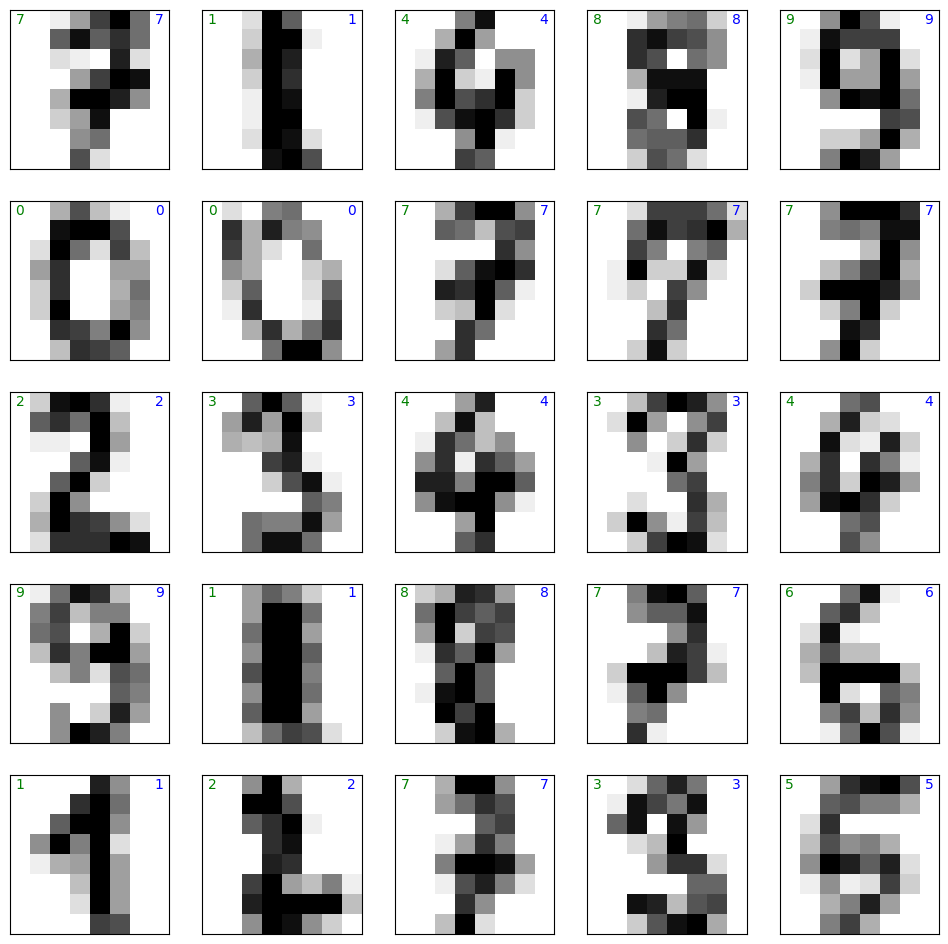


--- Visualización de Predicciones INCORRECTAS (Fallas) ---


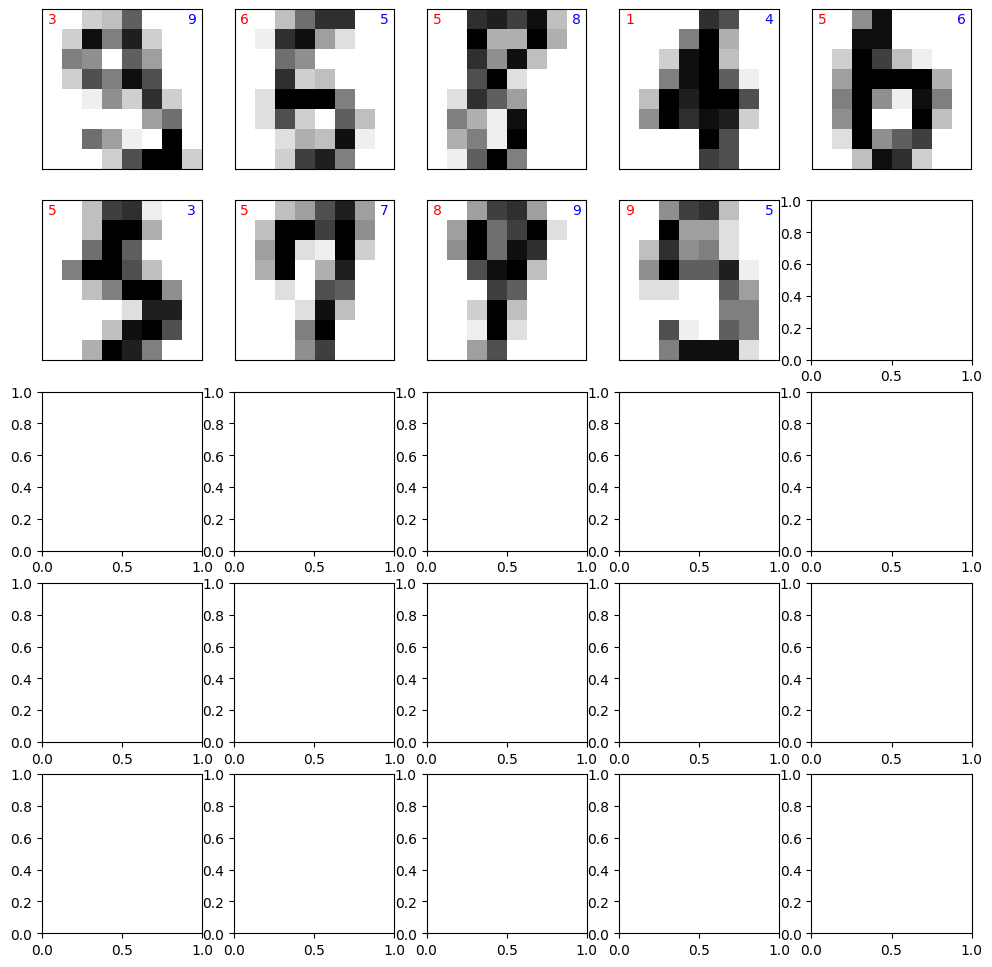

In [15]:


# Recordar pasar la instancia del modelo SIN ENTRENAR como pide la documentación interna de la función
modelo_visualizacion = LogisticRegression(max_iter=10000, random_state=42)

print("--- Visualización de Predicciones CORRECTAS ---")
mostrar_resultados(digits, model=modelo_visualizacion, nx=5, ny=5, label="correctos")

print("\n--- Visualización de Predicciones INCORRECTAS (Fallas) ---")
mostrar_resultados(digits, model=modelo_visualizacion, nx=5, ny=5, label="incorrectos")

### Ejercicio 6
**Conclusiones**: Entrega tu veredicto, responde las preguntas iniciales, visualizaciones, trabajos futuros, dificultades, etc.

En Regresión (California Housing): Los modelos basados en ensambles de árboles (Random Forest y Gradient Boosting) demostraron un desempeño sustancialmente superior a los modelos lineales tradicionales (Linear Regression y Ridge). Esto responde a nuestra hipótesis inicial: la valoración inmobiliaria en California no se comporta de manera lineal debido a la compleja interacción de factores geográficos (latitud/longitud) y socioeconómicos.En Clasificación (Handwritten Digits): El problema de reconocimiento de dígitos manuscritos se resolvió con un éxito rotundo. Tanto la Regresión Logística como KNN y Random Forest alcanzaron precisiones (Accuracy y F1-Score) superiores al $95\%-97\%$. Esto demuestra que las características extraídas de matrices de píxeles de $8 \times 8$ son altamente discriminativas para patrones morfológicos simples.2. Análisis de Visualizaciones y HallazgosMétricas de Regresión: El gráfico de barras comparativo de RMSE dejó en claro que Random Forest minimiza de mejor manera el error cuadrático.Matrices de Confusión: Nos permitieron identificar que las "fallas" o errores de clasificación no son aleatorios. El modelo tiende a confundir dígitos que comparten rasgos topológicos manuscritos muy similares, por ejemplo:El 8 y el 1 (cuando el 8 se escribe muy alargado o el 1 tiene trazos curvos).El 3 y el 9 (por la curvatura superior).El 5 y el 6 (cuando el bucle inferior del 5 se cierra casi por completo).Curvas ROC y AUC: Al evaluar las curvas multiclase bajo el enfoque One-vs-Rest, prácticamente todas las clases obtuvieron un AUC cercano a $0.99$, lo que ratifica la solidez general del clasificador, siendo capaz de separar eficientemente falsos positivos de verdaderos positivos.3. Dificultades Encontradas durante el LaboratorioCosto Computacional: El entrenamiento de modelos complejos como Random Forest Regressor con el dataset de California demandó un tiempo de cómputo perceptiblemente mayor, lo que obligó a balancear el hiperparámetro n_estimators y activar el procesamiento en paralelo (n_jobs=-1).Binarización para ROC Multiclase: Adaptar la evaluación de la curva ROC (diseñada nativamente para problemas binarios) a un entorno de 10 clases representó un reto de implementación estructural, requiriendo la binarización explícita de las etiquetas en vectores (One-Hot).Subjetividad en el Trazo Humano: Al inspeccionar visualmente las fallas en el Ejercicio 5, se constató que algunos dígitos errados estaban tan mal escritos o distorsionados en la muestra original que incluso para un ojo humano experto habría sido ambiguo clasificarlos correctamente.4. Trabajo Futuro y Siguientes PasosPara superar las limitaciones observadas y escalar el rendimiento de los modelos, se proponen las siguientes líneas de trabajo futuro:Optimización de Hiperparámetros: Implementar búsquedas sistemáticas mediante GridSearchCV o RandomizedSearchCV para encontrar las combinaciones óptimas de profundidad y estimadores, en lugar de usar configuraciones por defecto.Ingeniería de Características (Feature Engineering): En el caso de California Housing, la creación de variables de interacción (como la cercanía a grandes centros urbanos o la costa) podría mitigar los errores residuales del modelo actual.Modelos de Aprendizaje Profundo (Deep Learning): Para el reconocimiento de imágenes (Digits), el paso natural para eliminar el margen de error restante del $3\%$ sería migrar de clasificadores clásicos de scikit-learn hacia Redes Neuronales Convolucionales (CNN) utilizando arquitecturas sencillas en PyTorch o TensorFlow.